# SOB4ES - XGBoost Multisalida

### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluación de los modelos

Este notebook implementa **XGBoost con salida vectorial**, disponible desde la version 1.7 mediante el parámetro `multi_strategy='multi_output_tree'`.

A diferencia del enfoque individual (un modelo por target), aquí un único árbol de decisión en cada iteración del *boosting* aprende a predecir los 21 targets simultáneamente. 

Esto permite capturar correlaciones entre grupos biológicos de forma más directa que entrenar modelos separados.

**Datasets utilizados:**
- `train.csv` - Entrenamiento del modelo (70 % del total, estratificado por país)
- `test.csv` - Búsqueda de hiperparámetros y validación cruzada (15 %)
- `eval.csv` - Evaluación final e imparcial del rendimiento (15 %)
  
**Estructura del notebook:**
1. **Configuración:** importaciones y parámetros globales.
2. **Carga de datos:** se cargan los tres splits pre-generados.
3. **Tuning:** búsqueda del valor óptimo de los hiperparámetros.
4. **Validación cruzada:** evaluación de robustez.
5. **Explicabilidad (SHAP) / Importancia de variables:** análisis de importancia de variables.
6. **Producción:** entrenamiento final y exportación de modelos.
7. **Evaluación final:** rendimiento real sobre `eval.csv`.

## 1.- Configuración del entorno

En esta sección del notebook importaremos todas las librerías necesarias como también realizaremos las configuraciones iniciales.

In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path

import xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

import itertools
from matplotlib.colors import LinearSegmentedColormap

import matplotlib.pyplot as plt
import shap

warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/xgb_multi/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

print('Librerias y variables cargadas correctamente...')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}
# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Librerias y variables cargadas correctamente...


In [2]:

# Deteccion de GPU / CUDA

# Comprueba si hay una GPU NVIDIA disponible y, en ese caso, configura
# XGBoost para usarla automaticamente. Si no hay GPU (o XGBoost no fue
# compilado con soporte CUDA), se usa la CPU sin que falle nada.

import subprocess

def _detectar_cuda():
    """Comprueba si hay una GPU NVIDIA con drivers CUDA disponibles en el sistema."""
    try:
        resultado = subprocess.run(
            ['nvidia-smi'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            timeout=5,
        )
        return resultado.returncode == 0
    except (FileNotFoundError, subprocess.TimeoutExpired):
        return False

def _xgb_soporta_device():
    """XGBoost >= 2.0 usa el parametro 'device'; las versiones anteriores
    activan la GPU unicamente con tree_method='gpu_hist'."""
    try:
        return int(xgboost.__version__.split('.')[0]) >= 2
    except Exception:
        return False

CUDA_DISPONIBLE = _detectar_cuda()

if CUDA_DISPONIBLE and _xgb_soporta_device():
    # XGBoost >= 2.0: GPU via tree_method='hist' + device='cuda'
    XGB_DEVICE_PARAMS = {'tree_method': 'hist', 'device': 'cuda'}
elif CUDA_DISPONIBLE:
    # XGBoost < 2.0: GPU via tree_method='gpu_hist'
    XGB_DEVICE_PARAMS = {'tree_method': 'gpu_hist'}
else:
    XGB_DEVICE_PARAMS = {'tree_method': 'hist'}

print(f'GPU NVIDIA / CUDA detectada : {CUDA_DISPONIBLE}')
print(f'Version de XGBoost          : {xgboost.__version__}')
print(f'Parametros de dispositivo   : {XGB_DEVICE_PARAMS}')
if CUDA_DISPONIBLE:
    print('XGBoost usara la GPU para el tuning, la validacion y el entrenamiento de produccion.')
else:
    print('No se detecto GPU. XGBoost usara CPU (tree_method=\'hist\').')

# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

GPU NVIDIA / CUDA detectada : True
Version de XGBoost          : 3.3.0
Parametros de dispositivo   : {'tree_method': 'hist', 'device': 'cuda'}
XGBoost usara la GPU para el tuning, la validacion y el entrenamiento de produccion.
Nucleos disponibles: 16 | n_jobs asignado: 12


## 2.- Carga de datos

Se cargan los tres datasets pre-generados a partir de la división 70/15/15 estratificada por país.

| Archivo     | Uso                                      | Filas aprox. |
| ----------- | ---------------------------------------- | ------------ |
| `train.csv` | Ajuste del modelo                        | 299          |
| `test.csv`  | Tuning de hiperparametros / Val. cruzada | 64           |
| `eval.csv`  | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la sección 7 para garantizar una estimación imparcial del rendimiento.

In [3]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")

Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3.- Búsqueda de hiperparámetros (Tuning)

El espacio de búsqueda es idéntico al del XGBoost individual. 

El parámetro `multi_strategy='multi_output_tree'` activa la salida vectorial: en lugar de construir un árbol por target (comportamiento por defecto), construye un único árbol que predice todos los targets a la vez en cada iteración del _boosting_.

Al igual que con RF multisalida, el tuning usa un único target de referencia para el scoring y los parametros óptimos se aplican después al modelo completo multisalida.

Iniciando busqueda de hiperparametros (Tuning)...
Este proceso puede tardar bastante...

[ 1/21] Buscando hiperparametros para: nematode_shannon_z


  R2: 0.2175  |  tiempo: 1.5 min
[ 2/21] Buscando hiperparametros para: macro_shannon_z


  R2: 0.3285  |  tiempo: 1.5 min
[ 3/21] Buscando hiperparametros para: earthworm_shannon_z


  R2: 0.5027  |  tiempo: 1.4 min
[ 4/21] Buscando hiperparametros para: orib_shannon_z


  R2: 0.0963  |  tiempo: 1.4 min
[ 5/21] Buscando hiperparametros para: meso_shannon_z


...

  R2: -0.0189  |  tiempo: 1.4 min
[19/21] Buscando hiperparametros para: euk_asv_richness_z


  R2: 0.2741  |  tiempo: 1.5 min
[20/21] Buscando hiperparametros para: oomy_asv_richness_z


  R2: 0.2809  |  tiempo: 1.5 min
[21/21] Buscando hiperparametros para: cerc_asv_richness_z


  R2: 0.2136  |  tiempo: 1.4 min

Calculando consenso de hiperparametros (ponderado por R2 de los 21 targets)...
  Peso earthworm_richness_z          : 0.141
  Peso earthworm_shannon_z           : 0.120
  Peso macro_shannon_z               : 0.079
  Peso macro_order_richness_z        : 0.068
  Peso oomy_asv_richness_z           : 0.067
  ...

Hiperparametros consenso finales:
  n_estimators: 207
  max_depth: 4
  learning_rate: 0.03139066781580437
  subsample: 0.6699267538405558
  colsample_bytree: 0.7021338916961798
  gamma: 0.4574244751880444
  min_child_weight: 8
  reg_alpha: 2.5026629693131883
  reg_lambda: 5.3852575991816565
  max_leaves: 0
  scale_pos_weight: 1.0
  random_state: 42
  tree_method: hist
  device: cuda


<function matplotlib.pyplot.show(close=None, block=None)>

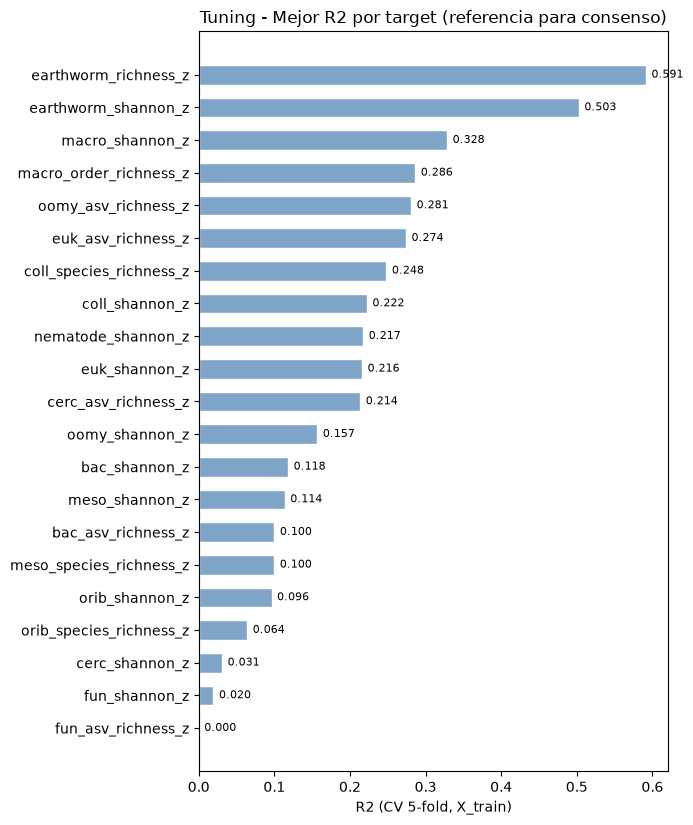

In [4]:
print("Iniciando busqueda de hiperparametros (Tuning)...")
print("Este proceso puede tardar bastante...\n")

param_grid = {
	'n_estimators':     [50, 100, 150, 200, 300],
	'learning_rate':    [0.01, 0.02, 0.03, 0.05],
	'max_depth':        [2, 3, 4],
	'subsample':        [0.5, 0.6, 0.7, 0.8],
	'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
	'min_child_weight': [5, 10, 15, 20],
	'gamma':            [0.2, 0.5, 1.0, 2.0],
	'reg_alpha':        [0.5, 1.0, 2.0, 5.0, 10.0],
	'reg_lambda':       [1.0, 2.0, 5.0, 10.0, 20.0],
	'scale_pos_weight': [1.0],
	'tree_method':      [XGB_DEVICE_PARAMS['tree_method']],
	'random_state':     [RANDOM_STATE],
    'multi_strategy':   ['multi_output_tree'],
}
if 'device' in XGB_DEVICE_PARAMS:
    param_grid['device'] = [XGB_DEVICE_PARAMS['device']]

resultados_tuning = {}

for idx, nombre_target in enumerate(TARGETS, 1):
    print(f"[{idx:2d}/{len(TARGETS)}] Buscando hiperparametros para: {nombre_target}")
    buscador = RandomizedSearchCV(
        estimator=XGBRegressor(**XGB_DEVICE_PARAMS, random_state=RANDOM_STATE),
        param_distributions=param_grid,
        n_iter=150,
        scoring='r2',
        cv=5,
        verbose=0,
        random_state=RANDOM_STATE,
        n_jobs= N_JOBS
    )
    start = time.time()
    buscador.fit(X_train, y_train[nombre_target].values)
    elapsed = (time.time() - start) / 60

    resultados_tuning[nombre_target] = {
        'params': buscador.best_params_,
        'r2':     buscador.best_score_,
    }
    print(f"  R2: {buscador.best_score_:.4f}  |  tiempo: {elapsed:.1f} min")

# Consenso de hiperparametros ponderado por R2 (ahora sobre los 21 targets)
r2_por_target = {t: max(resultados_tuning[t]['r2'], 0.0) for t in TARGETS}
suma_r2 = sum(r2_por_target.values())
if suma_r2 <= 0:
    pesos = {t: 1 / len(TARGETS) for t in TARGETS}
else:
    pesos = {t: v / suma_r2 for t, v in r2_por_target.items()}

print("\nCalculando consenso de hiperparametros (ponderado por R2 de los 21 targets)...")
for t in sorted(pesos, key=pesos.get, reverse=True)[:5]:
    print(f"  Peso {t:30}: {pesos[t]:.3f}")
print("  ...")

def consenso_int(key, default=0):
    return int(round(sum(pesos[t] * resultados_tuning[t]['params'].get(key, default) for t in TARGETS)))

def consenso_float(key, default=0.0):
    return sum(pesos[t] * resultados_tuning[t]['params'].get(key, default) for t in TARGETS)

def consenso_cat(key):
    mejor_target = max(pesos, key=pesos.get)
    return resultados_tuning[mejor_target]['params'][key]

def consenso_log(key):
    return float(np.exp(sum(pesos[t] * np.log(resultados_tuning[t]['params'][key]) for t in TARGETS)))

XGB_MULTI_PARAMS = {
    'n_estimators':      consenso_int('n_estimators'),
    'max_depth':         consenso_int('max_depth'),
    'learning_rate':     consenso_log('learning_rate'),
    'subsample':         consenso_float('subsample'),
    'colsample_bytree':  consenso_float('colsample_bytree'),
    'gamma':             consenso_float('gamma', 0.0),
    'min_child_weight':  consenso_int('min_child_weight'),
    'reg_alpha':         consenso_float('reg_alpha', 0.0),
    'reg_lambda':        consenso_float('reg_lambda', 1.0),
    'max_leaves':        consenso_int('max_leaves', 0),
    'scale_pos_weight':  1.0,    
    'random_state':      RANDOM_STATE,
}
XGB_MULTI_PARAMS.update(XGB_DEVICE_PARAMS)

print("\nHiperparametros consenso finales:")
for k, v in XGB_MULTI_PARAMS.items():
    print(f"  {k}: {v}")

# Grafico: R2 de tuning por target (ordenado)
_orden = sorted(r2_por_target, key=r2_por_target.get)
fig, ax = plt.subplots(figsize=(7, 0.35 * len(_orden) + 1))
_bars = ax.barh([t for t in _orden], [r2_por_target[t] for t in _orden], color=PALETTE['blue'], edgecolor='white', height=0.6)
ax.bar_label(_bars, fmt='{:.3f}', padding=4, fontsize=8)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target (referencia para consenso)', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show

## 4.- Validación cruzada

Se evalua la robustez con **validación cruzada repetida** (5 pliegues x 3 repeticiones) sobre `X_train` con todos los targets a la vez. 

Se muestra el R2 promedio global y el R2 individual por target.

In [5]:
print('Validacion cruzada repetida sobre X_train (todos los targets)...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

modelo_cv = XGBRegressor(**XGB_MULTI_PARAMS)

print('-' * 65)
print('Target: MULTI-OUTPUT (Promedio de todos los targets - XGBoost)')
print('-' * 65)

resultados = cross_validate(
    estimator=modelo_cv,
    X=X_train, 
    y=y_train,
    cv=cv_splitter,
    scoring=metricas,
    return_train_score=True
)

r2_train = np.mean(resultados['train_r2'])
r2_cv    = np.mean(resultados['test_r2'])
r2_std   = np.std(resultados['test_r2'])
rmse_cv  = np.mean(-resultados['test_neg_root_mean_squared_error'])
mae_cv   = np.mean(-resultados['test_neg_mean_absolute_error'])

print(f'  Train R2          : {r2_train:.4f}')
print(f'  Validacion R2 (CV): {r2_cv:.4f} +/- {r2_std:.4f}')
print(f'  RMSE global       : {rmse_cv:.4f}')
print(f'  MAE global        : {mae_cv:.4f}')

diferencia = r2_train - r2_cv
if diferencia > 0.15:
    print(f'  Aviso: diferencia train/val = {diferencia:.4f}. Posible sobreajuste.\n')
else:
    print(f'  Diferencia train/val = {diferencia:.4f}. El modelo generaliza correctamente.\n')

# R2 individual por target (entrenando sobre todo X_train)
modelo_cv.fit(X_train, y_train)
y_pred_train = modelo_cv.predict(X_train)

print('  R2 individual por target (Evaluado en train):')
print('-' * 65)
for i, t in enumerate(TARGETS):
    # Aseguramos compatibilidad si y_train es un DataFrame de Pandas
    y_true_col = y_train.iloc[:, i] if hasattr(y_train, 'iloc') else y_train[:, i]
    r2 = r2_score(y_true_col, y_pred_train[:, i])
    print(f'    {t:30} {r2:.4f}')
print()

Validacion cruzada repetida sobre X_train (todos los targets)...

-----------------------------------------------------------------
Target: MULTI-OUTPUT (Promedio de todos los targets - XGBoost)
-----------------------------------------------------------------


  Train R2          : 0.7107
  Validacion R2 (CV): 0.1684 +/- 0.0353
  RMSE global       : 0.8891
  MAE global        : 0.6671
  Aviso: diferencia train/val = 0.5423. Posible sobreajuste.



  R2 individual por target (Evaluado en train):
-----------------------------------------------------------------
    nematode_shannon_z             0.7163
    macro_shannon_z                0.7496
    earthworm_shannon_z            0.8076
    orib_shannon_z                 0.6940
    meso_shannon_z                 0.7039
    coll_shannon_z                 0.7387
    bac_shannon_z                  0.6569
    fun_shannon_z                  0.6849
    euk_shannon_z                  0.7066
    oomy_shannon_z                 0.7089
    cerc_shannon_z                 0.6363
    macro_order_richness_z         0.7223
    earthworm_richness_z           0.8368
    orib_species_richness_z        0.6938
    meso_species_richness_z        0.6752
    coll_species_richness_z        0.7413
    bac_asv_richness_z             0.6607
    fun_asv_richness_z             0.6393
    euk_asv_richness_z             0.7433
    oomy_asv_richness_z            0.7386
    cerc_asv_richness_z            0.7198



## 5.- Importancia de variables (SHAP)

XGBoost expone directamente la importancia de cada variable mediante `feature_importances_`, que en modo multisalida refleja el impacto global sobre todos los targets. 

Se complementa con permutation importance  y SHAP para una estimación mas fiable.

Calculando importancia de variables...

Calculando Permutation Importance (esto puede tardar un poco)...


Top 10 variables por importancia (Ordenado por Permutación):
                       XGBoost gain  Permutacion (R2)
soil_ph_z                    0.0419            0.0717
p_z                          0.0290            0.0438
gee_temp_media_C_z           0.0368            0.0412
dem_elevacion_m_z            0.0332            0.0336
soil_moisture_z              0.0285            0.0324
eu_as_z                      0.0388            0.0312
eu_p_z                       0.0337            0.0306
k_z                          0.0268            0.0303
gee_humedad_rel_pct_z        0.0350            0.0294
dem_orientacion_deg_z        0.0231            0.0277


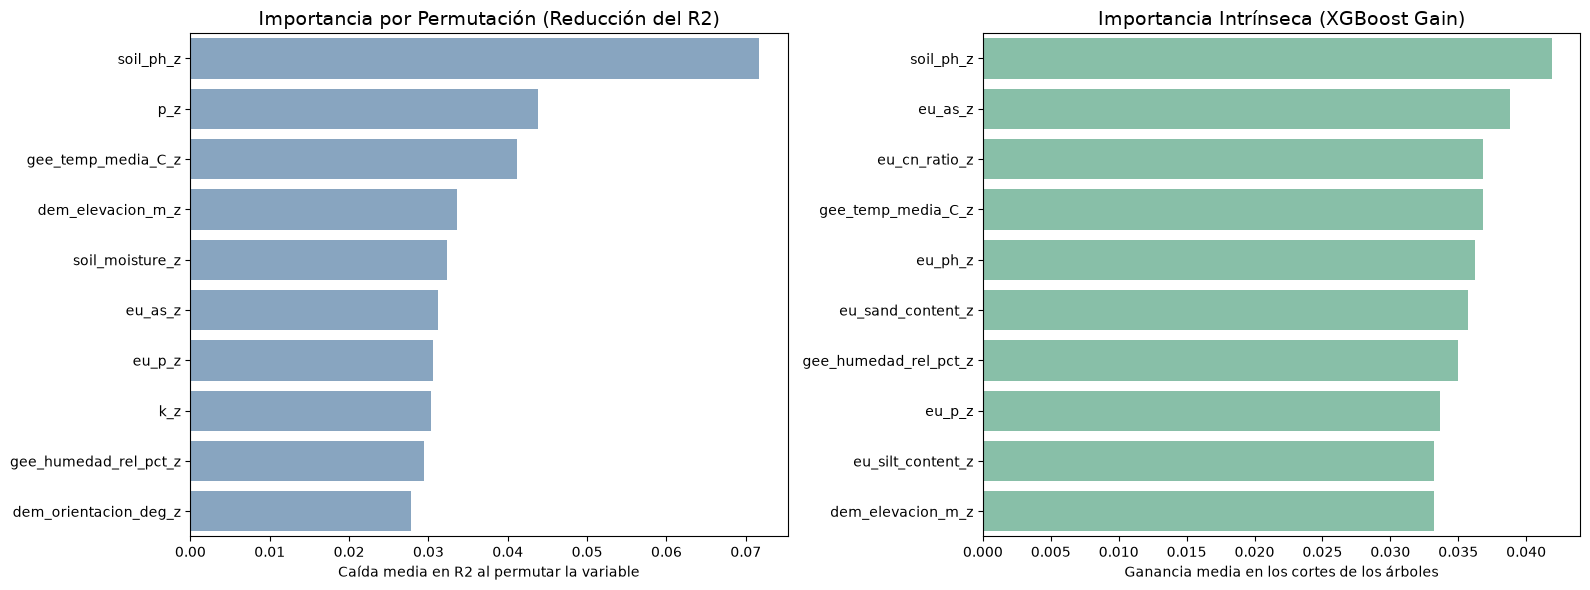


Calculando valores SHAP...
Variables más importantes para earthworm_shannon_z


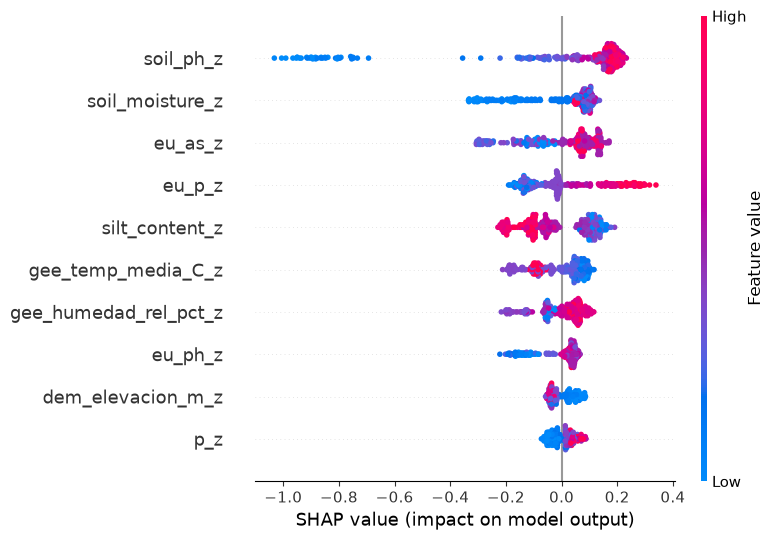

Variables más importantes para earthworm_richness_z


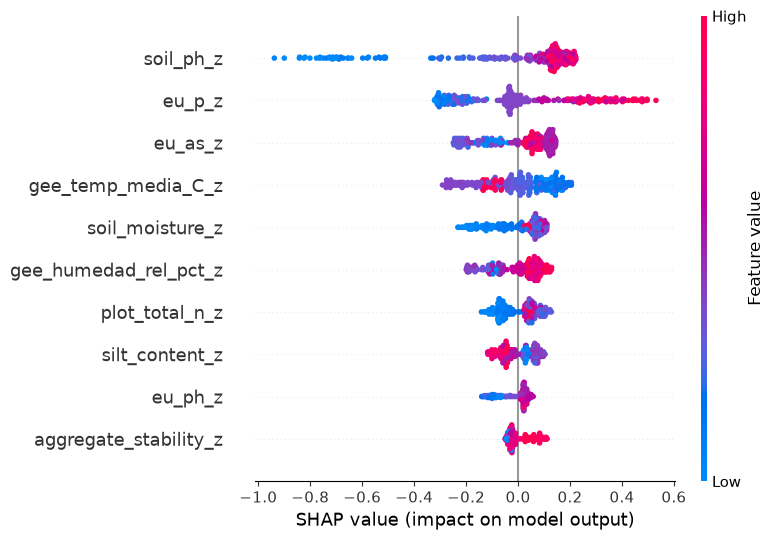

In [6]:
print('Calculando importancia de variables...\n')

# 1.- Cálculo de importancias

# Importancia intrinseca de XGBoost (gain medio por variable)
imp_xgb = pd.Series(modelo_cv.feature_importances_, index=FEATURES_AUTORIZADAS)

# Permutation importance sobre X_train
print('Calculando Permutation Importance (esto puede tardar un poco)...')
perm = permutation_importance(
    modelo_cv, X_train, y_train,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
imp_perm = pd.Series(perm.importances_mean, index=FEATURES_AUTORIZADAS)

# Unir en un DataFrame y extraer el Top 10
df_importancias = pd.DataFrame({
    'XGBoost gain': imp_xgb,
    'Permutacion (R2)': imp_perm
})

TOP_N = 10
top_features = df_importancias.sort_values('Permutacion (R2)', ascending=False).head(TOP_N)



print(f'Top {TOP_N} variables por importancia (Ordenado por Permutación):')
print(top_features.round(4).to_string())

# 2.- Gráficos de barras (Permutación vs XGBoost Gain)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Permutación
sns.barplot(x=top_features['Permutacion (R2)'], y=top_features.index, ax=axes[0], color=PALETTE['blue'])
axes[0].set_title('Importancia por Permutación (Reducción del R2)', fontsize=14)
axes[0].set_xlabel('Caída media en R2 al permutar la variable')
axes[0].set_ylabel('')

# Gráfico B: XGBoost Gain 
top_features_gain = df_importancias.sort_values('XGBoost gain', ascending=False).head(TOP_N)
sns.barplot(x=top_features_gain['XGBoost gain'], y=top_features_gain.index, ax=axes[1], color=PALETTE['green'])
axes[1].set_title('Importancia Intrínseca (XGBoost Gain)', fontsize=14)
axes[1].set_xlabel('Ganancia media en los cortes de los árboles')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


# 3.- Análisis SHAP (Shannon y Richness)

print('\nCalculando valores SHAP...')

# Lista de targets que queremos analizar con SHAP
targets_shap = ['earthworm_shannon_z', 'earthworm_richness_z']

for target in targets_shap:
    print(f"Variables más importantes para {target}")
    
    # Entrenamos un modelo rápido de un solo target con los mismos parámetros base
    modelo_shap = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, **XGB_DEVICE_PARAMS)

    # Intentamos copiar los hiperparámetros de los modelos generados
    try:
        if hasattr(modelo_cv, 'get_params'):
            modelo_shap.set_params(**modelo_cv.get_params())
    except Exception:
        pass # Si falla al copiar, usamos los parámetros base

    # Entrenamos solo con el target actual
    modelo_shap.fit(X_train, y_train[target])

    # Calculamos SHAP
    explainer = shap.TreeExplainer(modelo_shap)
    shap_values = explainer.shap_values(X_train)

    # Generamos el gráfico
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_train, plot_type='dot', max_display=TOP_N, show=True)

## 6.- Entrenamiento 

Se entrena un ensamble de 5 modelos XGBoost multisalida, variando la semilla aleatoria (semilla + n_modelo). 

Cada modelo predice los 21 targets a la vez con `multi_strategy='multi_output_tree'`.

In [7]:
print('Entrenamiento de produccion (ensamble de 5 modelos XGBoost multisalida)...')
print('-' * 70)

global_start = time.time()
NUM_EXPERTOS = 5

for exp_id in range(NUM_EXPERTOS):
    t0     = time.time()
    params = XGB_MULTI_PARAMS.copy()
    params['random_state'] = RANDOM_STATE + exp_id

    # Entrenamos sobre y_train completo (matriz 11 targets)
    model  = XGBRegressor(**params)
    model.fit(X_train, y_train)

    joblib.dump(model, os.path.join(MODELS_DIR, f'xgb_multi_exp{exp_id}.pkl'))
    print(f'  Modelo {exp_id+1}/5 completado ({time.time()-t0:.1f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')

Entrenamiento de produccion (ensamble de 5 modelos XGBoost multisalida)...
----------------------------------------------------------------------


  Modelo 1/5 completado (1.9s)


  Modelo 2/5 completado (1.9s)


  Modelo 3/5 completado (1.9s)


  Modelo 4/5 completado (1.9s)


  Modelo 5/5 completado (1.9s)
----------------------------------------------------------------------
Produccion completada en 0.2 minutos.


In [8]:
# PRUEBA 3 - Barrido de random_state (100-5000 en saltos de 10)

RANDOM_STATES = range(100, 5001, 10)
dir_barrido   = os.path.join(MODELS_DIR, 'barrido_rs_xgb_multi')
os.makedirs(dir_barrido, exist_ok=True)

resultados_rs = []
t_inicio = time.time()

for rs in RANDOM_STATES:
    t0 = time.time()
    params = XGB_MULTI_PARAMS.copy()
    params['random_state'] = rs

    model = XGBRegressor(**params)
    model.fit(X_train, y_train)

    y_pred_eval = model.predict(X_eval)
    y_true_eval = y_eval.values

    fila = {
        'random_state': rs,
        'r2_global':   r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average'),
        'rmse_global': np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average')),
        'mae_global':  mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average'),
    }
    for t, r2_t in zip(TARGETS, r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')):
        fila[f'{t}_r2'] = r2_t

    joblib.dump(model, os.path.join(dir_barrido, f'xgb_multi_rs{rs}.pkl'))
    resultados_rs.append(fila)
    if rs % 10 == 0:
        print(f'  rs={rs:3d} completado ({time.time()-t0:.1f}s)')

df_barrido_xgb_multi = pd.DataFrame(resultados_rs)
df_barrido_xgb_multi.to_csv(os.path.join(dir_barrido, 'xgb_multi_barrido_rs.csv'), index=False)
print(f'\nBarrido completado en {(time.time()-t_inicio)/60:.1f} minutos.')

  rs=100 completado (2.0s)


  rs=110 completado (2.0s)


  rs=120 completado (2.0s)


  rs=130 completado (2.0s)


  rs=140 completado (2.0s)


...

  rs=4960 completado (2.0s)


  rs=4970 completado (2.0s)


  rs=4980 completado (2.0s)


  rs=4990 completado (2.0s)


  rs=5000 completado (2.0s)

Barrido completado en 16.2 minutos.


## 7.- Evaluación final sobre eval.csv

Se usa `eval.csv` por primera vez para obtener una estimación real del rendimiento en producción. 
A continuación se ejecuta un smoke test para verificar que el pipeline de carga e inferencia funciona correctamente.

**Nota: Interpretacion del indice Shannon H':**

El modelo predice el índice de diversidad de Shannon, que va aproximadamente de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad biologica).

Evaluacion final sobre eval.csv (Ensamble XGBoost)
-----------------------------------------------------------------
  Target                               R2     RMSE      MAE
-----------------------------------------------------------------


  Global (Promedio)                0.0835   0.9187   0.6838
-----------------------------------------------------------------
  nematode_shannon_z               0.2228   0.8707   0.6737
  macro_shannon_z                  0.3771   0.7927   0.6529
  earthworm_shannon_z              0.5375   0.6788   0.4725
  orib_shannon_z                   0.2275   1.0051   0.8385
  meso_shannon_z                  -0.2861   1.1075   0.8883
  coll_shannon_z                  -0.3229   0.7286   0.5647
  bac_shannon_z                   -0.0151   1.0089   0.6857
  fun_shannon_z                   -0.0502   1.1725   0.9306
  euk_shannon_z                    0.0886   0.9259   0.6549
  oomy_shannon_z                   0.0620   1.0124   0.7385
  cerc_shannon_z                  -0.0330   0.9101   0.6371
  macro_order_richness_z           0.4013   0.7086   0.5880
  earthworm_richness_z             0.5893   0.5852   0.4240
  orib_species_richness_z          0.2800   1.0152   0.6813
  meso_species_richness_z         


  Target: earthworm_shannon_z
  ---------------------------------------------------------------
  Votos individuales por experto:
    Modelo 1 | Fila 53:  0.5139 | Fila 60:  0.9741 | Fila 0: -0.3550
    Modelo 2 | Fila 53:  0.5010 | Fila 60:  0.8811 | Fila 0: -0.3387
    Modelo 3 | Fila 53:  0.5463 | Fila 60:  0.9226 | Fila 0: -0.2996
    Modelo 4 | Fila 53:  0.5621 | Fila 60:  0.9504 | Fila 0: -0.3330
    Modelo 5 | Fila 53:  0.6387 | Fila 60:  0.9726 | Fila 0: -0.2951
  ---------------------------------------------------------------
  Consenso final frente a valores reales:
    Fila 53   | Consenso:  0.5524 | Valor Real:  1.1347 | Error: 0.5823
    Fila 60   | Consenso:  0.9402 | Valor Real:  1.1388 | Error: 0.1986
    Fila 0    | Consenso: -0.3243 | Valor Real: -0.7453 | Error: 0.4210

  Target: earthworm_richness_z
  ---------------------------------------------------------------
  Votos individuales por experto:
    Modelo 1 | Fila 53:  0.8651 | Fila 60:  1.1709 | Fila 0: -0.4407

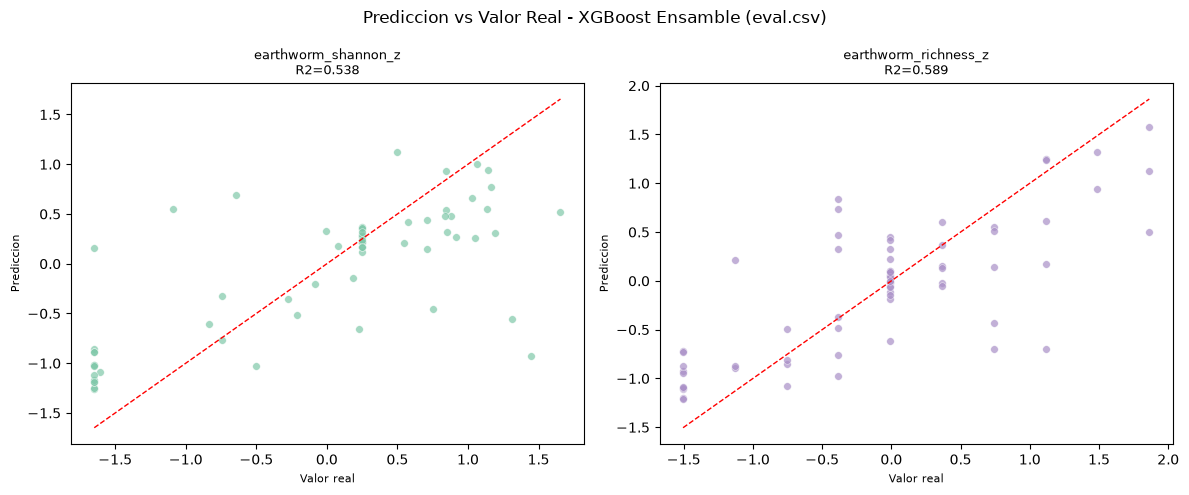

In [9]:
NUM_EXPERTOS = 5

# Evaluacion final
# Cargamos los 5 modelos expertos y promediamos sus predicciones sobre eval.csv.
print('Evaluacion final sobre eval.csv (Ensamble XGBoost)')
print('-' * 65)
print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

preds_eval = []
for exp_id in range(NUM_EXPERTOS):
    ruta  = os.path.join(MODELS_DIR, f'xgb_multi_exp{exp_id}.pkl')
    model = joblib.load(ruta)
    preds_eval.append(model.predict(X_eval))

# y_pred_eval es una matriz (n_muestras x len(TARGETS) targets)
y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

# Metricas globales
r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')

print(f'  {"Global (Promedio)":30} {r2_global:8.4f} {rmse_global:8.4f} {mae_global:8.4f}')
print('-' * 65)

# Metricas individuales por target
r2_por_target = r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')
for i, t in enumerate(TARGETS):
    rmse_t = np.sqrt(mean_squared_error(y_true_eval[:, i], y_pred_eval[:, i]))
    mae_t  = mean_absolute_error(y_true_eval[:, i], y_pred_eval[:, i])
    print(f'  {t:30} {r2_por_target[i]:8.4f} {rmse_t:8.4f} {mae_t:8.4f}')

print('-' * 65)

# Smoke test con datos reales
print('\nSmoke test - Inferencia con datos reales')
print('-' * 65)

try:
    df_new_data      = X_eval.sample(n=3, random_state=RANDOM_STATE)
    indices_elegidos = df_new_data.index

    # Generamos y guardamos las predicciones de todos los modelos del ensamble
    votos = []
    for exp_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_multi_exp{exp_id}.pkl')
        m     = joblib.load(ruta)
        votos.append(m.predict(df_new_data))

    # Promediamos para obtener el consenso final del ensamble
    consenso = np.mean(votos, axis=0)
    
    targets_smoke = ['earthworm_shannon_z', 'earthworm_richness_z']
    
    for tgt in targets_smoke:
        tgt_idx = TARGETS.index(tgt)
        print(f'\n  Target: {tgt}')
        print('  ' + '-' * 63)
        
        # Mostramos el voto de cada experto
        print('  Votos individuales por experto:')
        for exp_id in range(NUM_EXPERTOS):
            pred_experto = votos[exp_id]
            print(f'    Modelo {exp_id+1} | '
                  f'Fila {indices_elegidos[0]}: {pred_experto[0, tgt_idx]:>7.4f} | '
                  f'Fila {indices_elegidos[1]}: {pred_experto[1, tgt_idx]:>7.4f} | '
                  f'Fila {indices_elegidos[2]}: {pred_experto[2, tgt_idx]:>7.4f}')
        
        print('  ' + '-' * 63)
        print('  Consenso final frente a valores reales:')
        for i, idx in enumerate(indices_elegidos):
            pred_val = consenso[i, tgt_idx]
            real_val = y_eval.loc[idx, tgt]
            error    = abs(pred_val - real_val)
            print(f'    Fila {idx:<4} | Consenso: {pred_val:>7.4f} | '
                  f'Valor Real: {real_val:>7.4f} | Error: {error:>6.4f}')

    print('\n' + '-' * 65)
    print('Smoke test superado. El pipeline XGBoost multisalida funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real (targets principales)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    idx_col = TARGETS.index(tgt)
    
    preds = []
    for exp_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_multi_exp{exp_id}.pkl')
        preds.append(joblib.load(ruta).predict(X_eval))
    
    yp = np.mean(preds, axis=0)[:, idx_col]
    yt = y_eval[tgt].values
    
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
    
plt.suptitle('Prediccion vs Valor Real - XGBoost Ensamble (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()